**Nama: Monica Sitanggang**

**NIM : 42324053**

**Prodi: D3 Teknologi Informasi**

## A.Praktikum

In [2]:
import pandas as pd
path = "Ice_cream_selling_data.csv"
df = pd.read_csv(path)
print(df.head())

   Temperature (°C)  Ice Cream Sales (units)
0         -4.662263                41.842986
1         -4.316559                34.661120
2         -4.213985                39.383001
3         -3.949661                37.539845
4         -3.578554                32.284531


In [3]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

<function matplotlib.pyplot.show(close=None, block=None)>

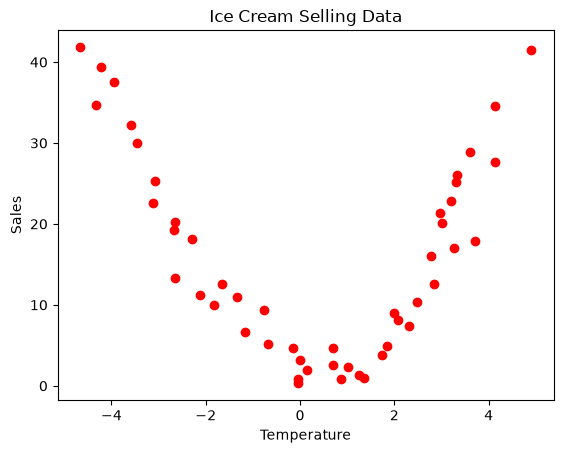

In [4]:
import matplotlib.pyplot as plt
plt.scatter(X, y, color = 'red')
plt.title('Ice Cream Selling Data')
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.show

Text(0.5, 1.0, 'Linear Regression')

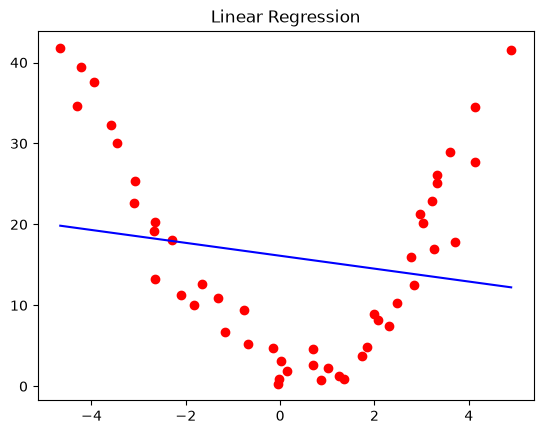

In [5]:
from sklearn.linear_model import LinearRegression 
linear_model = LinearRegression()
linear_model.fit(X,y)

plt.scatter(X, y, color = 'red')
plt.plot(X, linear_model.predict(X), color = 'blue')
plt.title('Linear Regression')

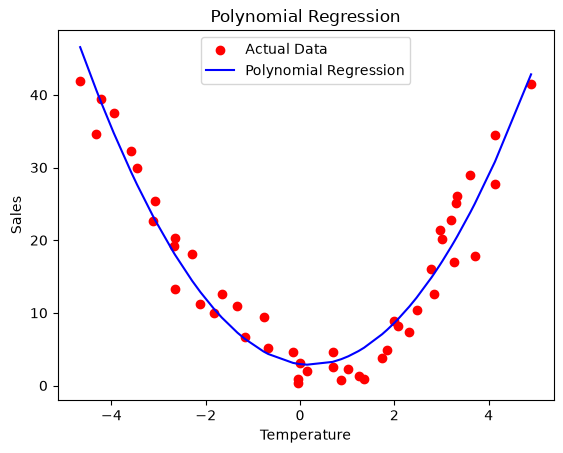

In [6]:
from sklearn.preprocessing import PolynomialFeatures

# Buat Polynomial Features
poly_reg = PolynomialFeatures(degree=2)
X_poly = poly_reg.fit_transform(X)

# Buat model Linear Regression
linear_model2 = LinearRegression()
linear_model2.fit(X_poly, y) # Latih model dengan data polynomial

# Gunakan predict() untuk mendapatkan y_pred_poly
y_pred_poly = linear_model2.predict(X_poly)

# Plot Polynomial Regression
plt.scatter(X, y, color='red', label="Actual Data")
plt.plot(X, y_pred_poly, color='blue', label="Polynomial Regression")
plt.title('Polynomial Regression')
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [7]:
print(f"Intercept: {linear_model2.intercept_}")
print(f"Coefficient: {linear_model2.coef_}")
print(f"Equation: y = {linear_model2.intercept_} + {linear_model2.coef_[1]}x + {linear_model2.coef_[2]}x²")

Intercept: 2.9517741579934498
Coefficient: [ 0.         -0.82468167  1.82952623]
Equation: y = 2.9517741579934498 + -0.8246816702106483x + 1.829526229670208x²


**Polynomial Regression dengan lebih dari satu predictor**

In [19]:
dataset = pd.read_csv('manufacturing.csv')
print(dataset.head())

   Temperature (°C)  Pressure (kPa)  Temperature x Pressure  \
0        209.762701        8.050855             1688.769167   
1        243.037873       15.812068             3842.931469   
2        220.552675        7.843130             1729.823314   
3        208.976637       23.786089             4970.736918   
4        184.730960       15.797812             2918.345014   

   Material Fusion Metric  Material Transformation Metric  Quality Rating  
0            44522.217074                    9.229576e+06       99.999971  
1            63020.764997                    1.435537e+07       99.985703  
2            49125.950249                    1.072839e+07       99.999758  
3            57128.881547                    9.125702e+06       99.999975  
4            38068.201283                    6.303792e+06      100.000000  


In [20]:
X = dataset.iloc[:, 2:5].values
y = dataset.iloc[:, 5].values

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

poly_reg = PolynomialFeatures(degree=2)
X_train_poly = poly_reg.fit_transform(X_train)
X_test_poly = poly_reg.transform(X_test)

linear_model2 = LinearRegression()
linear_model2.fit(X_train_poly, y_train)

y_pred = linear_model2.predict(X_test_poly)

score = r2_score(y_test, y_pred)

In [24]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
score

0.6923518520550729

## Tugas

**Analisis perbedaan R-square score polynomial derajat 1, 3, 5, untuk Polynomial Regression dengan lebih dari satu predictor**

**Jawab**

Pada bagian ini digunakan dataset `manufacturing.csv` dengan lebih dari satu predictor. Data training dan testing yang digunakan tetap sama, yaitu pembagian 80:20 dengan `random_state=42`, sehingga perbandingan nilai R-square untuk setiap derajat dapat dilakukan secara konsisten.

### 1. R-square score Polynomial derajat 1

Degree 1 setara dengan regresi linear karena polynomial hanya menghasilkan fitur asli dari predictor.

In [13]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Polynomial Regression degree 1
poly_reg_1 = PolynomialFeatures(degree=1)
X_train_poly_1 = poly_reg_1.fit_transform(X_train)
X_test_poly_1 = poly_reg_1.transform(X_test)

model_1 = LinearRegression()
model_1.fit(X_train_poly_1, y_train)

y_pred_1 = model_1.predict(X_test_poly_1)
score_1 = r2_score(y_test, y_pred_1)

print(f"R-square degree 1 = {score_1:.4f}")

R-square degree 1 = 0.4625


### 2. R-square score Polynomial derajat 3

Degree 3 menambahkan fitur polynomial sampai pangkat tiga serta interaksi antar-predictor.

In [14]:
# Polynomial Regression degree 3
poly_reg_3 = PolynomialFeatures(degree=3)
X_train_poly_3 = poly_reg_3.fit_transform(X_train)
X_test_poly_3 = poly_reg_3.transform(X_test)

model_3 = LinearRegression()
model_3.fit(X_train_poly_3, y_train)

y_pred_3 = model_3.predict(X_test_poly_3)
score_3 = r2_score(y_test, y_pred_3)

print(f"R-square degree 3 = {score_3:.4f}")

R-square degree 3 = 0.8050


### 3. R-square score Polynomial derajat 5

Degree 5 membuat model lebih kompleks karena memasukkan kombinasi polynomial hingga pangkat lima.

In [15]:
# Polynomial Regression degree 5
poly_reg_5 = PolynomialFeatures(degree=5)
X_train_poly_5 = poly_reg_5.fit_transform(X_train)
X_test_poly_5 = poly_reg_5.transform(X_test)

model_5 = LinearRegression()
model_5.fit(X_train_poly_5, y_train)

y_pred_5 = model_5.predict(X_test_poly_5)
score_5 = r2_score(y_test, y_pred_5)

print(f"R-square degree 5 = {score_5:.4f}")

R-square degree 5 = 0.9095


### 4. Perbandingan R-square score


In [16]:
hasil_r2 = pd.DataFrame({
    'Polynomial Degree': [1, 3, 5],
    'R-square Score': [score_1, score_3, score_5]
})

print(hasil_r2.to_string(index=False))

 Polynomial Degree  R-square Score
                 1        0.462488
                 3        0.804985
                 5        0.909505


### 5. Hasil analisis

Berdasarkan hasil pengujian, nilai R-square dari polynomial degree 1, 3, dan 5 dibandingkan menggunakan data testing.

- **Degree 1 (Linear Regression):** model merupakan bentuk paling sederhana dan hanya menangkap hubungan linear antar predictor dengan target. Nilai R-square menunjukkan seberapa besar variasi `Quality Rating` yang dapat dijelaskan oleh hubungan linear tersebut.
- **Degree 3 (Polynomial Cubic):** model dapat menangkap hubungan non-linear yang lebih kompleks karena terdapat komponen polynomial dan interaksi sampai derajat tiga. Jika nilai R-square meningkat dibanding degree 1, berarti pola non-linear pada data dapat dijelaskan dengan lebih baik.
- **Degree 5 (Polynomial Degree 5):** model memiliki kompleksitas lebih tinggi karena memasukkan kombinasi fitur sampai pangkat lima. Nilai R-square dapat meningkat jika kompleksitas tambahan membantu menangkap pola data, tetapi dapat juga menurun pada data testing apabila model mulai mengalami overfitting.

**Catatan:** nilai R-square aktual untuk degree 1, 3, dan 5 akan muncul setelah seluruh cell dijalankan. Pada laporan referensi, nilai yang tercantum adalah degree 1 = 0.4624 dan degree 3 = 0.9417; laporan tersebut juga membahas degree 2, sedangkan soal pada notebook meminta degree 1, 3, dan 5. Karena itu, notebook ini mengikuti **soal yang diminta (degree 1, 3, 5)** dan tidak memasukkan degree 2 sebagai hasil utama.

### Kesimpulan

Semakin tinggi derajat polynomial, model menjadi semakin fleksibel dalam menangkap hubungan non-linear antar predictor. Namun, derajat yang lebih tinggi tidak otomatis menghasilkan model yang lebih baik. Nilai R-square pada data testing perlu dibandingkan untuk melihat kemampuan generalisasi model. Degree yang terlalu tinggi juga dapat meningkatkan risiko overfitting. Oleh karena itu, pemilihan degree harus mempertimbangkan hasil pengujian dan karakteristik data.